In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [3]:
#Import Dataset
file_path = "C:/Users/ankur/Downloads/FastagFraudDetection_Cleaned_With_Location.xlsx"

df = pd.read_excel(file_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (5000, 21)

Columns:
['Transaction_ID', 'Timestamp', 'Vehicle_Type', 'FastagID', 'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount', 'Amount_paid', 'Geographical_Location', 'Vehicle_Speed', 'Vehicle_Plate_Number', 'Fraud_indicator', 'Latitude', 'Longitude', 'Real_Geographical_Location', 'City', 'District', 'State', 'Country', 'Postal_Code']


,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,...,Vehicle_Plate_Number,Fraud_indicator,Latitude,Longitude,Real_Geographical_Location,City,District,State,Country,Postal_Code
0,1,NaT,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",...,KA11AB1234,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
1,2,NaT,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",...,KA66CD5678,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
2,3,NaT,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",...,KA88EF9012,Not Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
3,4,NaT,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",...,KA11GH3456,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
4,5,NaT,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",...,KA44IJ6789,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114


In [4]:
#Dataset Overview
#Objective: Understand the size, structure, data types and basic statistics

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Dataset Shape: (5000, 21)

Column Names:
['Transaction_ID', 'Timestamp', 'Vehicle_Type', 'FastagID', 'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount', 'Amount_paid', 'Geographical_Location', 'Vehicle_Speed', 'Vehicle_Plate_Number', 'Fraud_indicator', 'Latitude', 'Longitude', 'Real_Geographical_Location', 'City', 'District', 'State', 'Country', 'Postal_Code']

Data Types:
Transaction_ID                         int64
Timestamp                     datetime64[ns]
Vehicle_Type                          object
FastagID                              object
TollBoothID                           object
Lane_Type                             object
Vehicle_Dimensions                    object
Transaction_Amount                     int64
Amount_paid                            int64
Geographical_Location                 object
Vehicle_Speed                          int64
Vehicle_Plate_Number                  object
Fraud_indicator                       object
Latitude           

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,...,Vehicle_Plate_Number,Fraud_indicator,Latitude,Longitude,Real_Geographical_Location,City,District,State,Country,Postal_Code
0,1,NaT,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",...,KA11AB1234,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
1,2,NaT,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",...,KA66CD5678,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
2,3,NaT,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",...,KA88EF9012,Not Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
3,4,NaT,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",...,KA11GH3456,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
4,5,NaT,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",...,KA44IJ6789,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114



Statistical Summary:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Transaction_ID,5000.0,NaN,NaN,NaN,2500.5,1.0,1250.75,2500.5,3750.25,5000.0,1443.520003
Timestamp,3041,NaN,NaN,NaN,2023-06-21 02:53:33.146991104,2023-01-13 00:45:00,2023-03-20 16:30:00,2023-05-31 07:15:00,2023-09-18 01:30:00,2023-12-31 21:45:00,NaN
Vehicle_Type,5000,7,Bus,716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FastagID,4451,4451,FTG-001-ABC-121,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TollBoothID,5000,6,B-102,1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lane_Type,5000,2,Regular,2858,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Dimensions,5000,3,Large,2144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction_Amount,5000.0,NaN,NaN,NaN,161.062,0.0,100.0,130.0,290.0,350.0,112.44995
Amount_paid,5000.0,NaN,NaN,NaN,141.261,0.0,90.0,120.0,160.0,350.0,106.480996
Geographical_Location,5000,5,"13.059816123454882, 77.77068662374292",1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#Vehicle Category/Dimension → Expected Payment

vehicle_combinations = (
    df.groupby(
        ["Vehicle_Type", "Vehicle_Dimensions"]
    )["Transaction_Amount"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Min="min",
        Max="max"
    )
    .reset_index()
)

display(
    vehicle_combinations.round(2)
)

,Vehicle_Type,Vehicle_Dimensions,Count,Mean,Median,Min,Max
0,Bus,Large,716,322.15,330.0,290,350
1,Car,Small,714,88.12,90.0,60,120
2,Motorcycle,Small,714,0.00,0.0,0,0
3,SUV,Large,714,148.99,145.0,130,180
4,Sedan,Medium,714,120.92,115.0,100,160
5,Truck,Large,714,321.85,330.0,290,350
6,Van,Medium,714,124.94,125.0,110,140


In [6]:
#Check whether each combination has a consistent toll

consistency = (
    df.groupby(
        ["Vehicle_Type", "Vehicle_Dimensions"]
    )["Transaction_Amount"]
    .nunique()
    .reset_index(name="Unique_Transaction_Amounts")
)

display(consistency)

,Vehicle_Type,Vehicle_Dimensions,Unique_Transaction_Amounts
0,Bus,Large,5
1,Car,Small,5
2,Motorcycle,Small,1
3,SUV,Large,5
4,Sedan,Medium,5
5,Truck,Large,5
6,Van,Medium,5


In [7]:
#Include TollBoothID: This is probably important because toll rates can differ by toll booth.

booth_vehicle_amount = (
    df.groupby(
        [
            "TollBoothID",
            "Vehicle_Type",
            "Vehicle_Dimensions"
        ]
    )["Transaction_Amount"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Unique_Amounts="nunique"
    )
    .reset_index()
)

display(
    booth_vehicle_amount.round(2)
)

,TollBoothID,Vehicle_Type,Vehicle_Dimensions,Count,Mean,Median,Unique_Amounts
0,A-101,Bus,Large,4,350.00,350.0,1
1,A-101,Car,Small,710,87.94,90.0,5
2,A-101,Sedan,Medium,714,120.92,115.0,5
3,B-102,Car,Small,4,120.00,120.0,1
4,B-102,SUV,Large,714,148.99,145.0,5
5,B-102,Van,Medium,714,124.94,125.0,5
6,C-103,Bus,Large,712,321.99,330.0,5
7,C-103,Truck,Large,714,321.85,330.0,5
8,D-104,Motorcycle,Small,40,0.00,0.0,1
9,D-105,Motorcycle,Small,104,0.00,0.0,1


In [8]:
#Identify the expected amount

expected_amount = (
    df.groupby(
        [
            "TollBoothID",
            "Vehicle_Type",
            "Vehicle_Dimensions"
        ]
    )["Transaction_Amount"]
    .median()
    .reset_index()
    .rename(
        columns={
            "Transaction_Amount": "Expected_Amount"
        }
    )
)

display(expected_amount.head(20))

,TollBoothID,Vehicle_Type,Vehicle_Dimensions,Expected_Amount
0,A-101,Bus,Large,350.0
1,A-101,Car,Small,90.0
2,A-101,Sedan,Medium,115.0
3,B-102,Car,Small,120.0
4,B-102,SUV,Large,145.0
5,B-102,Van,Medium,125.0
6,C-103,Bus,Large,330.0
7,C-103,Truck,Large,330.0
8,D-104,Motorcycle,Small,0.0
9,D-105,Motorcycle,Small,0.0


In [9]:
#Merge expected amount back into the data

df = df.merge(
    expected_amount,
    on=[
        "TollBoothID",
        "Vehicle_Type",
        "Vehicle_Dimensions"
    ],
    how="left"
)

In [10]:
#Compare Amount Paid with Expected Amount

df["Payment_Difference"] = (
    df["Amount_paid"] - df["Expected_Amount"]
)

In [11]:
df["Expected_Payment_Mismatch"] = (
    df["Payment_Difference"] != 0
).astype(int)

In [12]:
#Analyze mismatch by vehicle category

vehicle_mismatch = (
    df.groupby(
        ["Vehicle_Type", "Vehicle_Dimensions"]
    )["Expected_Payment_Mismatch"]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values(
        "Expected_Payment_Mismatch",
        ascending=False
    )
)

display(vehicle_mismatch.round(2))

,Vehicle_Type,Vehicle_Dimensions,Expected_Payment_Mismatch
3,SUV,Large,83.61
4,Sedan,Medium,83.47
6,Van,Medium,83.19
0,Bus,Large,83.10
5,Truck,Large,82.91
1,Car,Small,78.29
2,Motorcycle,Small,0.00


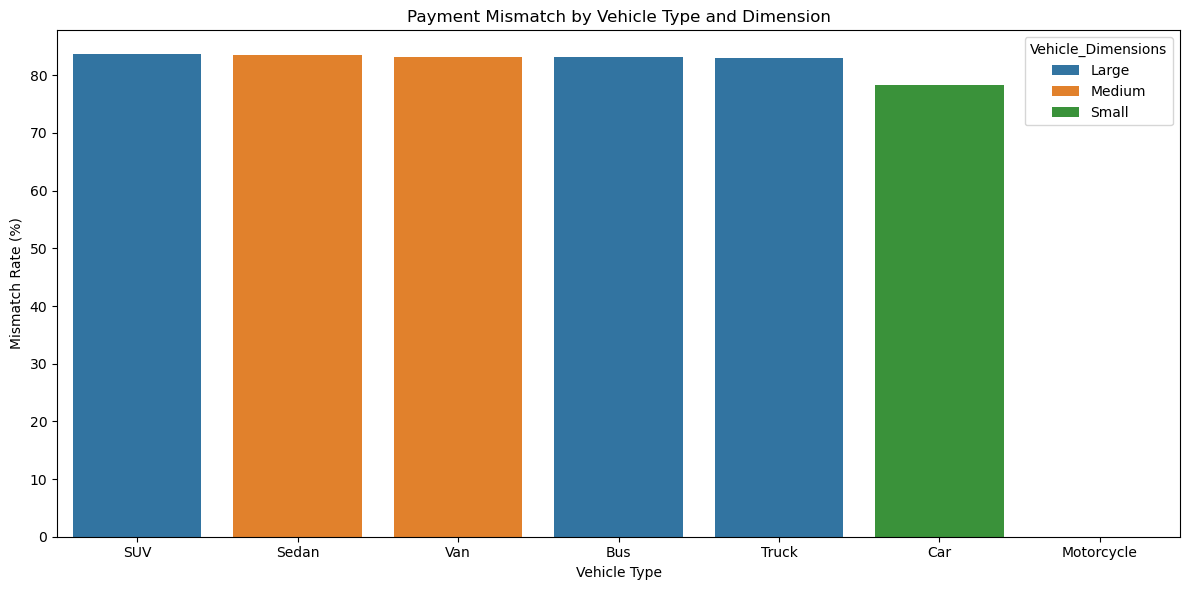

In [13]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=vehicle_mismatch,
    x="Vehicle_Type",
    y="Expected_Payment_Mismatch",
    hue="Vehicle_Dimensions"
)

plt.title(
    "Payment Mismatch by Vehicle Type and Dimension"
)

plt.xlabel("Vehicle Type")
plt.ylabel("Mismatch Rate (%)")

plt.tight_layout()
plt.show()

In [14]:
#create the binary target:

df["Fraud_Label"] = (
    df["Fraud_indicator"]
    .str.strip()
    .str.lower()
    .eq("fraud")
    .astype(int)
)

In [15]:
#Vehicle Speed vs Fraud

from scipy.stats import pointbiserialr

corr, p_value = pointbiserialr(
    df["Vehicle_Speed"],
    df["Fraud_Label"]
)

print("Vehicle Speed")
print("Correlation:", round(corr, 4))
print("P-value:", round(p_value, 4))

Vehicle Speed
Correlation: 0.0146
P-value: 0.3022


In [16]:
#Four categorical variables vs Fraud

from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

categorical_vars = [
    "Vehicle_Type",
    "Vehicle_Dimensions",
    "TollBoothID",
    "Lane_Type"
]

def cramers_v(table):
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape

    phi2 = chi2 / n

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = (
        r - ((r - 1) ** 2) / (n - 1)
    )

    kcorr = (
        k - ((k - 1) ** 2) / (n - 1)
    )

    return np.sqrt(
        phi2corr /
        min(kcorr - 1, rcorr - 1)
    )

results = []

for variable in categorical_vars:

    contingency_table = pd.crosstab(
        df[variable],
        df["Fraud_Label"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    v = cramers_v(contingency_table.values)

    results.append({
        "Variable": variable,
        "Chi-Square": chi2,
        "P-Value": p_value,
        "Cramers_V": v
    })

categorical_results = pd.DataFrame(results)

display(
    categorical_results
    .sort_values("Cramers_V", ascending=False)
    .round(4)
)

,Variable,Chi-Square,P-Value,Cramers_V
0,Vehicle_Type,227.3676,0.0,0.2104
2,TollBoothID,219.3486,0.0,0.2071
1,Vehicle_Dimensions,156.4278,0.0,0.1758
3,Lane_Type,24.1806,0.0,0.0681


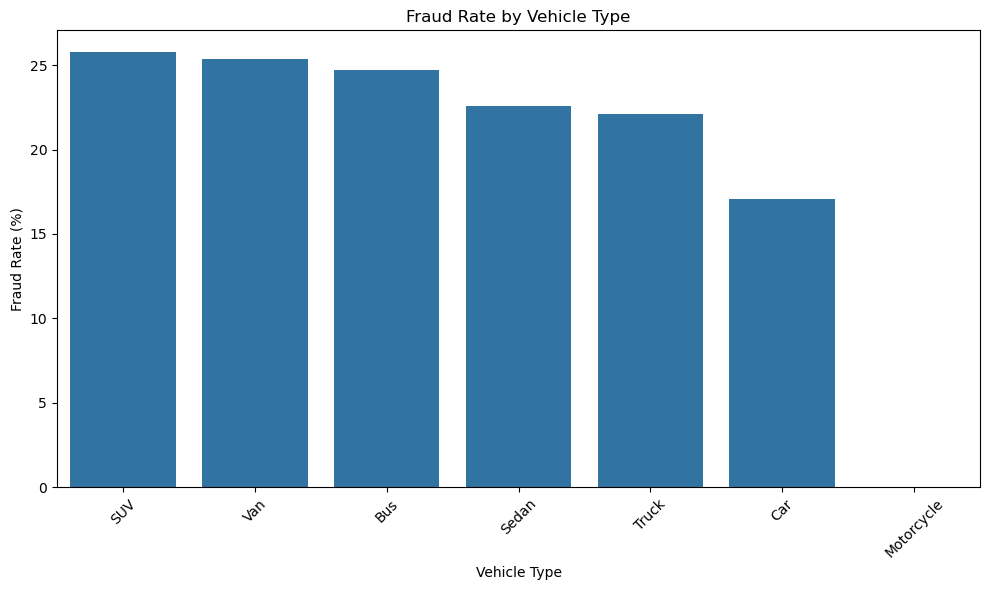

In [17]:
#Vehicle Type vs Fraud: Graph

import matplotlib.pyplot as plt
import seaborn as sns

vehicle_fraud = (
    df.groupby("Vehicle_Type")["Fraud_Label"]
      .mean()
      .mul(100)
      .reset_index()
      .sort_values("Fraud_Label", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=vehicle_fraud,
    x="Vehicle_Type",
    y="Fraud_Label"
)

plt.title("Fraud Rate by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

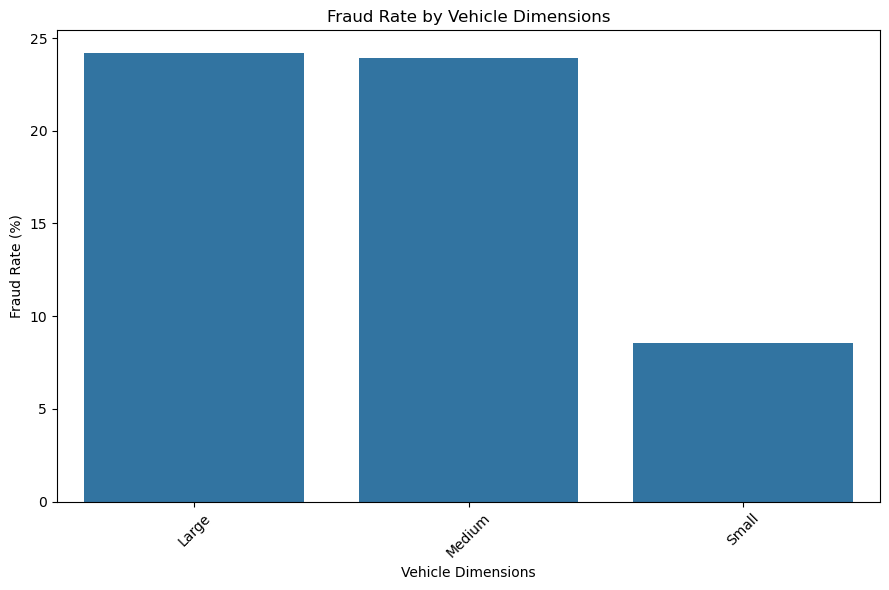

In [18]:
#Vehicle Dimensions vs Fraud: Graph

dimension_fraud = (
    df.groupby("Vehicle_Dimensions")["Fraud_Label"]
      .mean()
      .mul(100)
      .reset_index()
      .sort_values("Fraud_Label", ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=dimension_fraud,
    x="Vehicle_Dimensions",
    y="Fraud_Label"
)

plt.title("Fraud Rate by Vehicle Dimensions")
plt.xlabel("Vehicle Dimensions")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

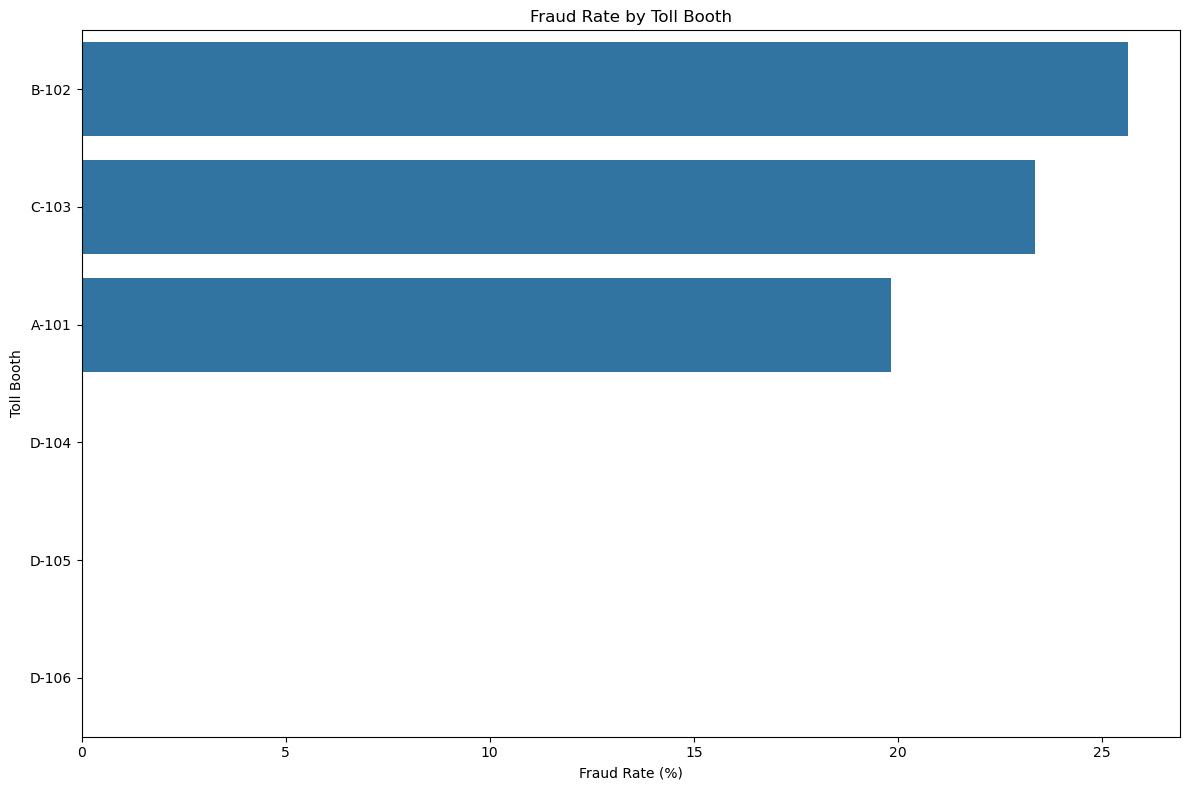

In [19]:
#TollBoothID vs Fraud: Graph

booth_fraud = (
    df.groupby("TollBoothID")["Fraud_Label"]
      .mean()
      .mul(100)
      .reset_index()
      .sort_values("Fraud_Label", ascending=False)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=booth_fraud,
    x="Fraud_Label",
    y="TollBoothID"
)

plt.title("Fraud Rate by Toll Booth")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Toll Booth")

plt.tight_layout()
plt.show()

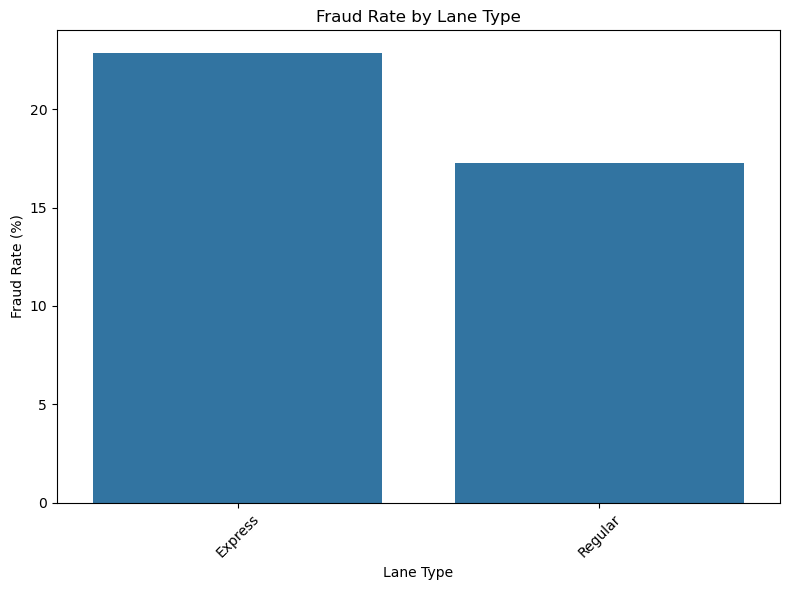

In [20]:
#Lane Type vs Fraud: Graph

lane_fraud = (
    df.groupby("Lane_Type")["Fraud_Label"]
      .mean()
      .mul(100)
      .reset_index()
      .sort_values("Fraud_Label", ascending=False)
)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=lane_fraud,
    x="Lane_Type",
    y="Fraud_Label"
)

plt.title("Fraud Rate by Lane Type")
plt.xlabel("Lane Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

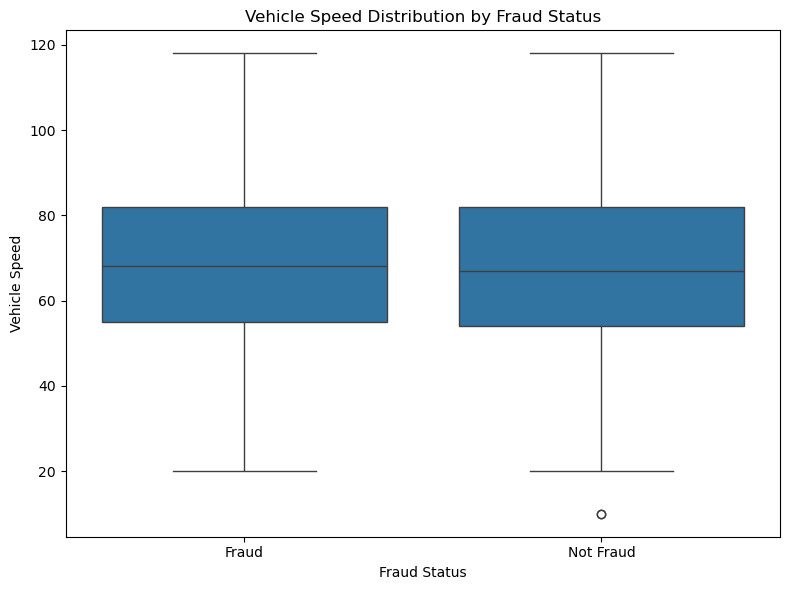

In [21]:
#Vehicle Speed vs Fraud: Graph

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Fraud_indicator",
    y="Vehicle_Speed"
)

plt.title("Vehicle Speed Distribution by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Vehicle Speed")

plt.tight_layout()
plt.show()

In [22]:
from scipy.stats import pointbiserialr

corr, p_value = pointbiserialr(
    df["Vehicle_Speed"],
    df["Fraud_Label"]
)

print("Point-Biserial Correlation:", round(corr, 4))
print("P-value:", round(p_value, 4))

Point-Biserial Correlation: 0.0146
P-value: 0.3022


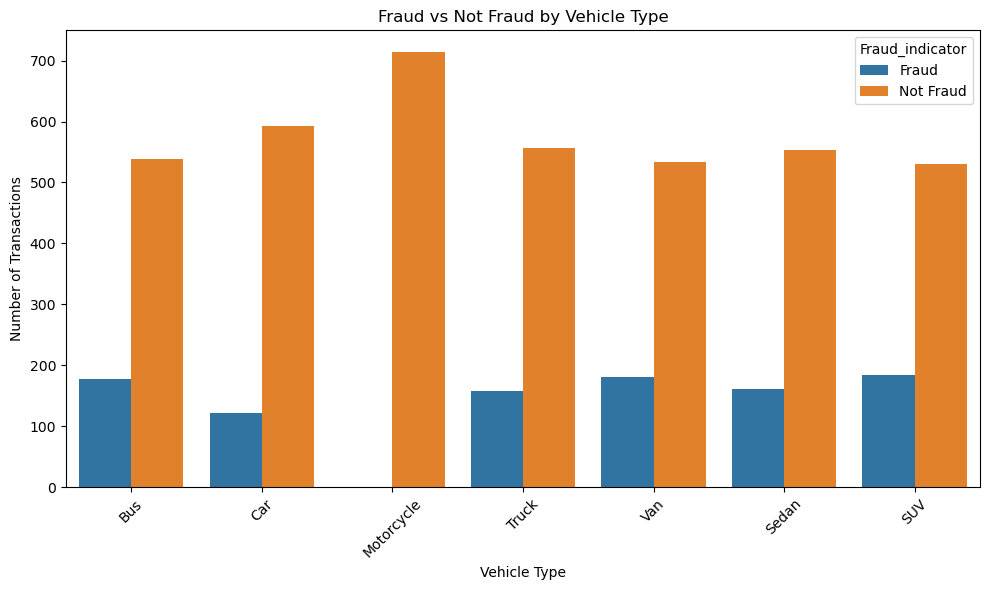

In [23]:
#Actual Fraud vs Not Fraud counts.

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Vehicle_Type",
    hue="Fraud_indicator"
)

plt.title("Fraud vs Not Fraud by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

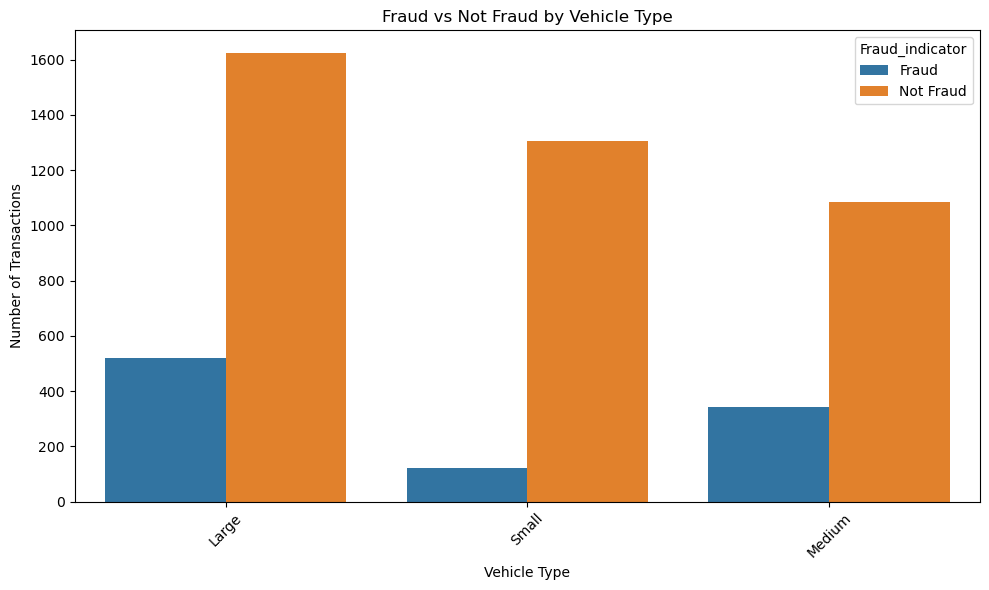

In [24]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Vehicle_Dimensions",
    hue="Fraud_indicator"
)

plt.title("Fraud vs Not Fraud by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

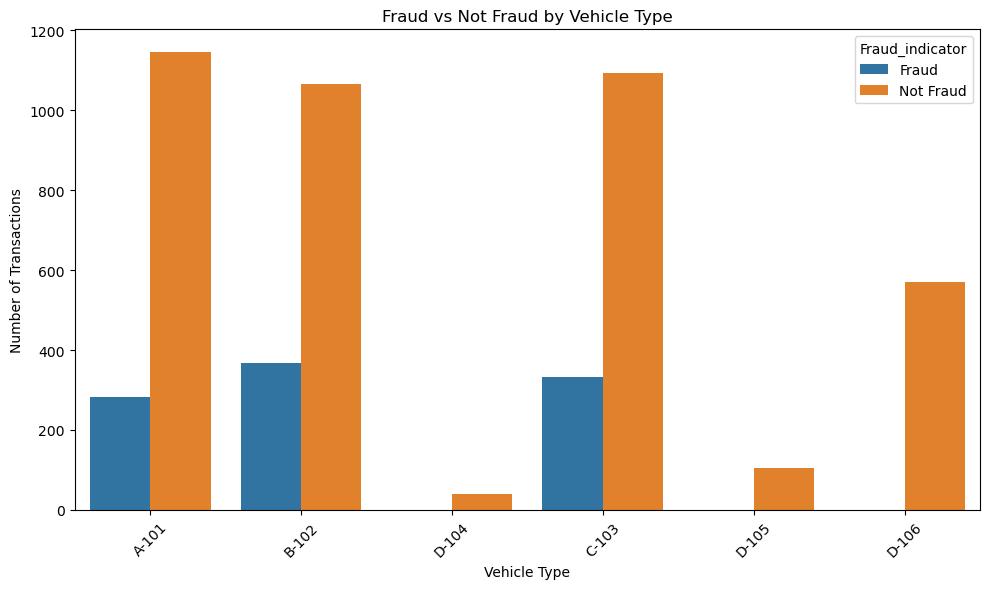

In [25]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="TollBoothID",
    hue="Fraud_indicator"
)

plt.title("Fraud vs Not Fraud by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

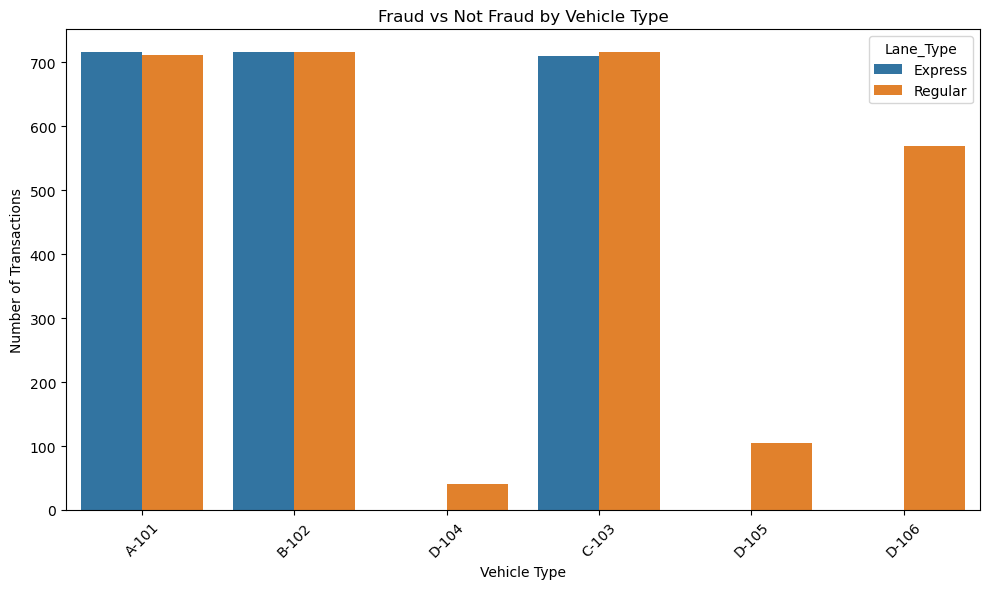

In [26]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="TollBoothID",
    hue="Lane_Type"
)

plt.title("Fraud vs Not Fraud by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

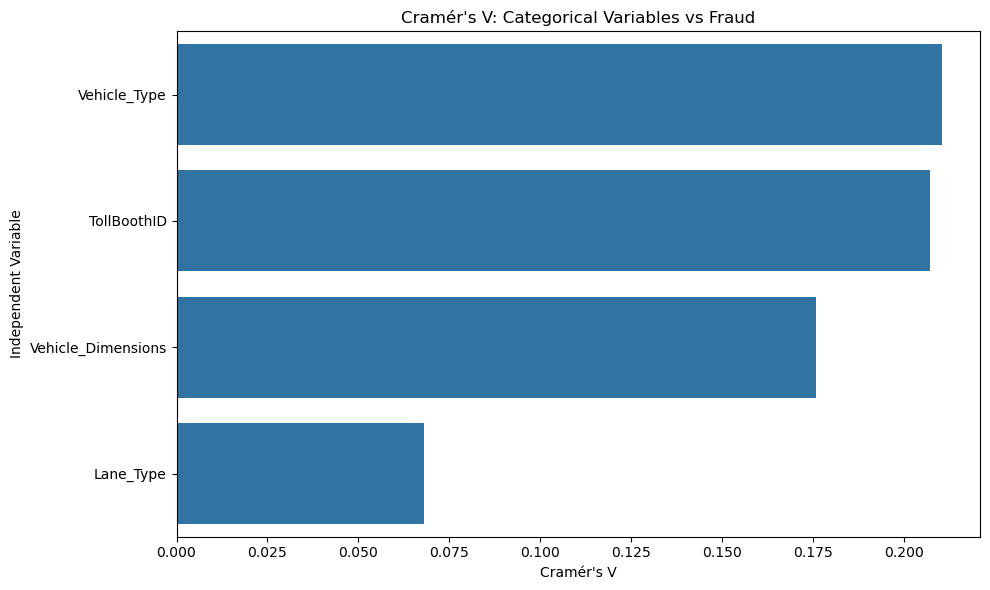

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=categorical_results.sort_values(
        "Cramers_V",
        ascending=False
    ),
    x="Cramers_V",
    y="Variable"
)

plt.title("Cramér's V: Categorical Variables vs Fraud")
plt.xlabel("Cramér's V")
plt.ylabel("Independent Variable")

plt.tight_layout()
plt.show()

             Variable  Association
0        Vehicle_Type     0.210433
1  Vehicle_Dimensions     0.175760
2         TollBoothID     0.207070
3           Lane_Type     0.068096
4       Vehicle_Speed     0.014594


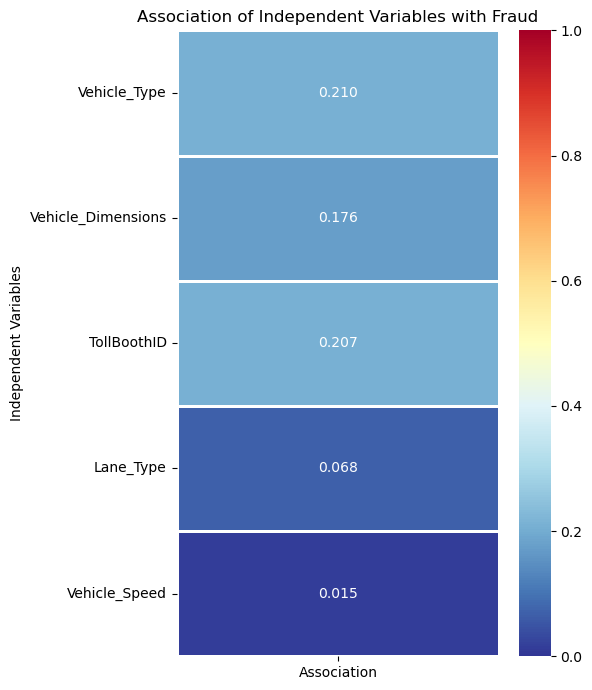

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pointbiserialr


# --------------------------------------------------
# 1. Create binary fraud label
# --------------------------------------------------

df["Fraud_Label"] = (
    df["Fraud_indicator"]
    .str.strip()
    .str.lower()
    .eq("fraud")
    .astype(int)
)


# --------------------------------------------------
# 2. Cramér's V function
# --------------------------------------------------

def cramers_v(table):

    chi2 = chi2_contingency(table)[0]

    n = table.sum().sum()

    r, k = table.shape

    phi2 = chi2 / n

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = (
        r - ((r - 1) ** 2) / (n - 1)
    )

    kcorr = (
        k - ((k - 1) ** 2) / (n - 1)
    )

    return np.sqrt(
        phi2corr /
        min(kcorr - 1, rcorr - 1)
    )


# --------------------------------------------------
# 3. Calculate association values
# --------------------------------------------------

association = {}

# Categorical variables
categorical_vars = [
    "Vehicle_Type",
    "Vehicle_Dimensions",
    "TollBoothID",
    "Lane_Type"
]

for col in categorical_vars:

    table = pd.crosstab(
        df[col],
        df["Fraud_Label"]
    )

    association[col] = cramers_v(table.values)


# Numerical variable
corr, p_value = pointbiserialr(
    df["Vehicle_Speed"],
    df["Fraud_Label"]
)

association["Vehicle_Speed"] = abs(corr)


# --------------------------------------------------
# 4. Convert to DataFrame
# --------------------------------------------------

association_df = pd.DataFrame(
    association.items(),
    columns=["Variable", "Association"]
)

print(association_df)


# --------------------------------------------------
# 5. Create Heatmap
# --------------------------------------------------

heatmap_data = association_df.set_index(
    "Variable"
)

plt.figure(figsize=(6, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="RdYlBu_r",
    linewidths=1,
    vmin=0,
    vmax=1
)

plt.title(
    "Association of Independent Variables with Fraud"
)

plt.xlabel("")
plt.ylabel("Independent Variables")

plt.tight_layout()
plt.show()

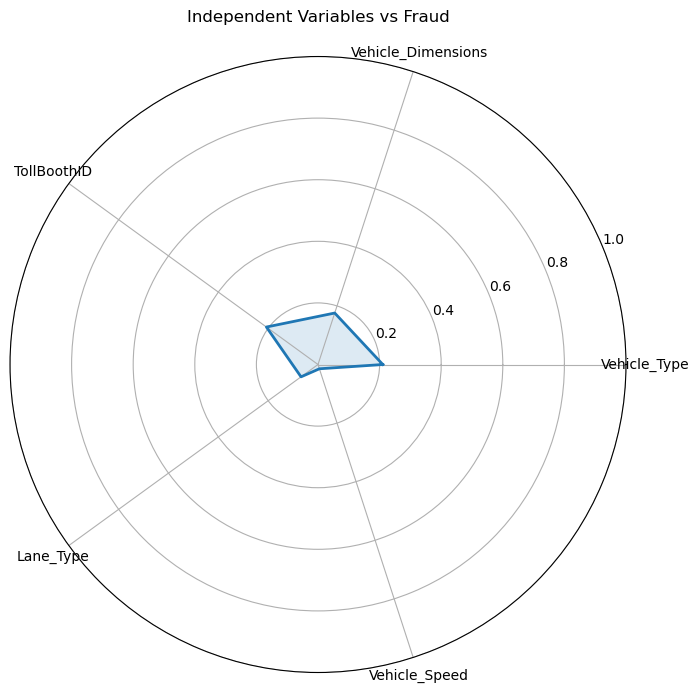

In [29]:
import numpy as np
import matplotlib.pyplot as plt

labels = association_df["Variable"].tolist()
values = association_df["Association"].tolist()

N = len(labels)

angles = np.linspace(
    0,
    2 * np.pi,
    N,
    endpoint=False
).tolist()

values += values[:1]
angles += angles[:1]

fig = plt.figure(figsize=(8, 8))

ax = plt.subplot(111, polar=True)

ax.plot(
    angles,
    values,
    linewidth=2
)

ax.fill(
    angles,
    values,
    alpha=0.15
)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)

ax.set_title(
    "Independent Variables vs Fraud",
    pad=25
)

plt.show()